# Diabetes Project

Your task today is to **analyse** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has diabetes or not, with the logistic regression you learned this week.

The task below follows the steps of a machine learning project: today you make a single pass through them, without the tuning loop you will learn in week 3.

![Today's single pass through the workflow: steps 1 to 4 (goal and metric, get the data, train-test split, explore and clean), then steps 5 to 8, where you build a random baseline, a rule-based baseline, a logistic regression and optional versions of it, and step 9, where every model is scored on the training and the test set](assets/diabetes_project_workflow.png)

# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

## Task

1. **Set your goal.**
    - **Choose your metric.** Before you model anything, decide which evaluation metric matters most for this problem, and explain why. Think about which mistake is worse for a patient: a missed diabetes case or a false alarm.
    - **Formulate a research question and three hypotheses**. The research question states what you want to find out about the patients. Each hypothesis is a statement about the data that the data can support or contradict, written in the form *"if ..., then ..."* or *"the more ..., the more ..."*. Base them on the data description above and on what you know about diabetes, not on the data itself, and note which column you will use to check each one. Write them into the table below the task.
2. **Load the data** from `data/diabetes.csv`, and take a first look at its size and columns.
3. **Split the data into a training and a test set** before you explore it. Use `train_test_split` once. Choose the size of the test set with `test_size`, use `stratify` on `Outcome`, so that both sets keep the same share of diabetes cases, and fix the `random_state`, so that you get the same split every time you run the notebook. Keep the features and the target together: the result should be two DataFrames, `df_train` and `df_test`, that both still contain the `Outcome` column. With the target in `df_train`, you can compare patients with and without diabetes while you explore. Do not look at `df_test` until step 8.
4. **Explore and clean the training set.** Work out what each column means and whether its values make sense. Some columns hide missing values as zeros: find them and decide how to handle them.

   Then **check your three hypotheses** on the cleaned training set, each with a plot and a number (for example, the share of patients with diabetes in different groups). Then back each hypothesis with a **statistical test** from the hypothesis testing session: check first whether the values are normally distributed, choose the test accordingly, and remember that you run three tests, not one. Give each hypothesis a verdict: **supported**, **contradicted** or **cannot tell yet**. Do not write "proved": a test tells you how likely the result is under the null hypothesis, and a single sample cannot prove a hypothesis. Add anything you did not expect to the "found along the way" row.


> [!IMPORTANT]
> **Keep a record of every change you make to the training data, and of the values you use.** In step 8 you apply exactly the same changes to the test set, using only information from the training data.
>
> If you fill missing values in the training set with its median, you will later fill the missing values in the test set with that **same training median**, not with its own. If you drop a column from the training set, you will drop it from the test set as well. Never calculate anything from the test data: it stands in for new patients your model has never seen, and you would not know their values in advance.

1. **Separate the features from the target, and build two baselines.** Split `df_train` into `X_train` and `y_train`; the test set stays untouched until step 8. Then build two simple models that your logistic regression has to beat:
    - a **random baseline** with [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html), which predicts at random in the proportions of the two classes in the training set. Fix its `random_state` as well, and
    - a **rule-based baseline** that uses the column you found most strongly related to diabetes in step 4, for example *"a value above ... means diabetes"*. Choose the cut-off on the training data.
2. **Train a logistic regression** with as many features as possible: use all the columns that are left after cleaning.
3. **Optional: handle the class imbalance.** Most patients in this dataset do not have diabetes, so a model tends to miss real cases. You can try two ways to catch more of them:
    - train with `class_weight="balanced"`, which makes each diabetes case count more during training (see the [`class_weight` parameter](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)), and
    - lower the decision threshold, using `predict_proba` instead of `predict`. Choose the threshold with the training scores, never with the test set.

   **Save every model in its own variable** (for example `dummy`, `logreg` and `logreg_balanced`, and the cut-off of your rule), so that you can evaluate all of them in the last step.
4. **Prepare the test set and evaluate all models at the very end.** First apply to `df_test` the same cleaning steps you applied to the training data in step 4, with the values learned on the training data, and split it into `X_test` and `y_test`. Then calculate the **training and the test scores of every model** with your chosen metric and the other classification metrics, and collect them in **one table**: one row per model, with columns for the training and the test scores. Then compare the models: which ones beat the baselines, and how large is the difference between training and test scores? Explain what your best model gets right, and where it still makes mistakes.

> [!TIP]
> A confusion matrix makes the trade-off visible: count how many diabetes cases each version misses, and how many false alarms it raises.

## Metric

**Main metric: F2**, with "develops diabetes within five years" (`Outcome = 1`) as the positive class, and a **precision floor `P_min = 0.5`**.

- **Why missing a case is worse:** `Outcome = 1` means that diabetes was diagnosed 1 to 5 years *after* the examination, so the model makes a prognosis, not a diagnosis. A false negative is a missed chance for prevention (lifestyle advice, close monitoring). A false positive costs an unnecessary check-up and some worry.
- **Why β = 2:** F-beta weights a false negative β² times as heavily as a false positive. We assume that a missed case weighs about as much as four false alarms, so β = 2. This is an assumption, not a fact.
- **Why a precision floor:** F2 rewards predicting too many patients as positive. `P_min = 0.5` means at most one unnecessary check-up per future case found. After the split we check that `P_min` lies clearly above the share of positive cases in the training set, which is the precision of "everyone has diabetes".
- **How we use it:** we choose the decision threshold on the training data so that F2 is as high as possible while precision stays at or above `P_min`. Accuracy appears in the results table only as a warning light.

## Research Question and Hypotheses

Fill in the research question and the first three columns in step 1, before you explore the data. Fill in the verdicts in step 4.

**Research question:** Which characteristics measured at the examination indicate that a Pima woman will develop diabetes within the next five years?

| | Hypothesis | Column(s) to check | Verdict (supported / contradicted / cannot tell yet) |
| :-- | :-- | :-- | :-- |
| H1 | The higher a woman's BMI at the examination, the more likely she is to develop diabetes within the next five years. | `BMI` (0 = missing, replaced by NaN) | **supported.** Mann-Whitney U (one-tailed), p = 1.6e-15 < 0.0167, rank-biserial r = 0.39: the BMI values of women who develop diabetes tend to be higher (median 34.4 vs. 30.1). In 70 % of random pairs, the woman who develops diabetes has the higher BMI. |
| H2 | The more pregnancies a woman has had, the more likely she is to develop diabetes within the next five years (bands: 0 / 1–3 / 4–6 / 7+). | `Pregnancies` (0 is a real value) | **cannot tell yet.** χ² = 39.4 (3 degrees of freedom), p = 1.4e-8, Cramér's V = 0.25: the share of diabetes depends on the band, but it does not rise steadily (0: 0.37, 1–3: 0.25, 4–6: 0.32, 7+: 0.57). The effect comes from the band 7+, which is also the oldest group (median age 42 vs. 24–34), so age may explain it. |
| H3 | If a woman develops diabetes within the next five years, then her 2-hour insulin level at the examination differs from that of women who do not. The direction is open: higher through insulin resistance, or lower through failing insulin production. | `Insulin` (0 = missing, replaced by NaN) | **supported, direction: higher.** Mann-Whitney U (two-tailed), p = 6.5e-14, rank-biserial r = 0.51: insulin tends to be higher in women who develop diabetes (median 168 vs. 100), which fits insulin resistance. Limits: only 324 of 614 rows have a value (missing in 46 % and 49 % of the two groups), and insulin correlates with glucose (Spearman ρ = 0.67). |
| Found along the way | (1) The highest glucose value is 199, just below the diabetic limit of 200 in the paper: the Kaggle data match the paper's selection rule. (2) Whenever SkinThickness is missing, Insulin is missing too (175 of 175 rows), which points to how the examinations were run. (3) Women with 0 pregnancies develop diabetes more often (0.37) than women with 1–3 (0.25). (4) Outlier candidates: SkinThickness 99 mm, diastolic blood pressure 24 and 30 mmHg; kept, see step 4.6. | `Glucose`, `SkinThickness`, `Insulin`, `Pregnancies`, `BloodPressure` | described only, not tested (no extra tests beyond the three) |

**Test plan (fixed before looking at the data):** three tests, so Bonferroni α = 0.05 / 3 ≈ 0.0167.
- H1: Shapiro per group, then Welch t-test or Mann-Whitney U, one-tailed (greater).
- H2: χ² test on the pregnancy bands × `Outcome`, with Cramér's V as effect size.
- H3: Mann-Whitney U, two-tailed, because the direction is open. Report how many cases per `Outcome` group drop out because of missing insulin values.

In [1]:
# Import the libraries you need for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

## Step 2: Load the data

Only size, columns and data types here. Distributions, `describe()` and plots come after the split, on `df_train` only.

In [2]:
df = pd.read_csv("data/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**What we see:** 768 rows and 9 columns, the same number of examinations as in the paper. All columns are numbers (`int64` or `float64`), so nothing needs converting.

`df.info()` reports 768 non-null values in every column, so it looks as if nothing were missing. But the first rows already show `Insulin = 0` and `SkinThickness = 0`: the missing values hide as zeros, and pandas cannot know that a 0 here means "not measured".

**Cleaning rule fixed before the split:** in these five columns a value of 0 is biologically impossible, so it stands for a missing measurement and becomes NaN. `Pregnancies = 0` is a real value, and so is `Outcome = 0`. The rule is fixed in advance and learns nothing from the data, so it may run before the split. Filling the NaNs (with a median) happens later, with values from the training set only.

In [4]:
# How often does 0 appear in each column, before the replacement?
zeros_before = (df == 0).sum()
zeros_before

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [5]:
ZERO_MEANS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[ZERO_MEANS_MISSING] = df[ZERO_MEANS_MISSING].replace(0, np.nan)

In [6]:
# After the replacement: the zeros in the five columns have become NaN, the zeros elsewhere stay real zeros
zero_check = pd.DataFrame({
    "zeros before": zeros_before,
    "zeros after": (df == 0).sum(),
    "NaN after": df.isna().sum(),
})
assert (zero_check.loc[ZERO_MEANS_MISSING, "zeros before"] == zero_check.loc[ZERO_MEANS_MISSING, "NaN after"]).all()
zero_check

,zeros before,zeros after,NaN after
Pregnancies,111,111,0
Glucose,5,0,5
BloodPressure,35,0,35
SkinThickness,227,0,227
Insulin,374,0,374
BMI,11,0,11
DiabetesPedigreeFunction,0,0,0
Age,0,0,0
Outcome,500,500,0


**What we see:** the table puts the zeros before the replacement next to the zeros and NaNs after it.

- **Insulin: 374 of 768 (48.7 %)** are missing, almost every second woman. **SkinThickness: 227 (29.6 %).** BloodPressure (35), BMI (11) and Glucose (5) are missing only rarely.
- `Pregnancies` keeps its 111 zeros and `Outcome` its 500 zeros: these are real values (no pregnancy, no diabetes), and they were not touched.
- The `assert` confirms that every zero in the five columns has become exactly one NaN.

Counting on all 768 rows, before the split, is fine here: the column list was fixed beforehand, and the count only checks that the replacement worked. It does not influence any decision. Everything that does (missing values per group, medians) is computed on `df_train` only.

## Step 3: Split the data

One split, 20 % test set, stratified on `Outcome`, `random_state=42` (agreed within the pair, so that we both get the same split). Features and target stay together. From here on we only look at `df_train`; `df_test` stays untouched until step 8.

In [7]:
df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["Outcome"], random_state=42
)
print("train:", df_train.shape, "| test:", df_test.shape)

train: (614, 9) | test: (154, 9)


**Why we check `P_MIN` against `p_train`:**

- `P_MIN = 0.5` is the precision floor from our metric. We need it again in step 7, where we choose the threshold with the highest F2 among those that keep precision at or above `P_MIN`.
- `Outcome` contains only 0 and 1, so its mean is the share of positive cases: `p_train` = 214 / 614 ≈ 0.349.
- The simplest possible model, "everyone has diabetes", finds every real case (recall = 1.0), but every healthy woman becomes a false alarm. Its precision is TP / (TP + FP) = 214 / 614 = `p_train`.
- If `P_MIN` were at or below `p_train`, even this useless model would pass the floor, and the floor would protect against nothing. With 0.5 it lies clearly above 0.349, so the check prints `True`.

In [8]:
P_MIN = 0.5

p_train = df_train["Outcome"].mean()
print(f"Share of positive cases in train: {p_train:.3f}")
print(f"P_min = {P_MIN} lies above the precision of 'everyone has diabetes': {P_MIN > p_train}")

Share of positive cases in train: 0.349
P_min = 0.5 lies above the precision of 'everyone has diabetes': True


## Step 4: Explore and clean the training set

### 4.1 Where are the values missing?

If a column is missing more often in one `Outcome` group than in the other, the values are not missing completely at random (MCAR). Then a test on the remaining rows only looks at a selected subgroup, and filling with one median blurs the difference between the groups.

In [9]:
missing_share = df_train[ZERO_MEANS_MISSING].isna().groupby(df_train["Outcome"]).mean().T
missing_share.columns = ["share missing, Outcome 0", "share missing, Outcome 1"]
missing_share["rows missing"] = df_train[ZERO_MEANS_MISSING].isna().sum()
missing_share.round(3)

,"share missing, Outcome 0","share missing, Outcome 1",rows missing
Glucose,0.005,0.009,4
BloodPressure,0.030,0.051,23
SkinThickness,0.270,0.313,175
Insulin,0.462,0.491,290
BMI,0.018,0.009,9


In [10]:
# Are Insulin and SkinThickness missing in the same rows?
pd.crosstab(
    df_train["Insulin"].isna(), df_train["SkinThickness"].isna(),
    rownames=["Insulin missing"], colnames=["SkinThickness missing"],
)

SkinThickness missing,False,True
Insulin missing,,
False,324,0
True,115,175


**What we see:**

- **Missing share per group:** Insulin is missing in 46.2 % (Outcome 0) and 49.1 % (Outcome 1) of the training rows, SkinThickness in 27.0 % and 31.3 %. The other columns are rarely missing. So whether a value is missing hardly depends on `Outcome`. For H3 this means: the 324 women with an insulin value are not a group strongly selected by the outcome.
- **Careful with the wording:** this does not prove MCAR. Missingness could still depend on other columns, for example age (that would be MAR). It only shows that it does not depend on the outcome, just as "fail to reject" is not "accept".
- **Crosstab:** whenever SkinThickness is missing, Insulin is missing too (175 of 175 rows, the empty cell top right). The other way round this does not hold: in 115 rows only Insulin is missing. This points to the examination procedure: for some women neither measurement was taken at all, rather than single values being lost at random. → "Found along the way".
- Only **322 of 614** training rows are complete in all columns.

### 4.2 How are the values distributed?

The skew decides how we fill missing values (median for skewed columns) and, together with the histograms and the Shapiro test, which test we use for H1 and H3. Rule of thumb: |skew| below 0.5 is roughly symmetric, above 1 is strongly skewed.

In [11]:
FEATURES = df_train.columns.drop("Outcome")

df_train[FEATURES].skew().round(2).sort_values(ascending=False)

Insulin                     2.00
DiabetesPedigreeFunction    1.82
Age                         1.13
Pregnancies                 0.89
SkinThickness               0.75
BMI                         0.57
Glucose                     0.55
BloodPressure               0.11
dtype: float64

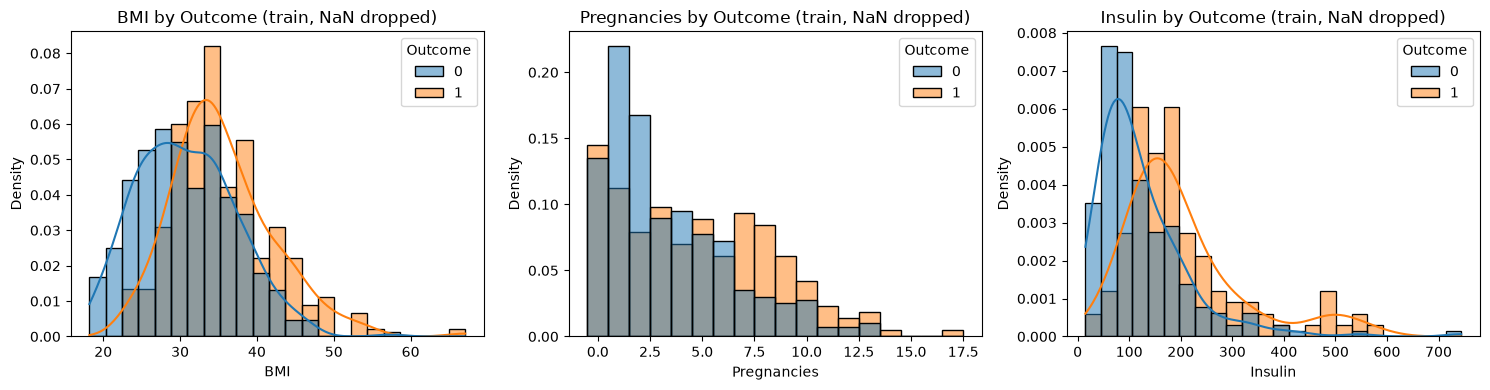

In [12]:
HYPOTHESIS_COLUMNS = ["BMI", "Pregnancies", "Insulin"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, HYPOTHESIS_COLUMNS):
    sns.histplot(
        data=df_train, x=col, hue="Outcome", stat="density", common_norm=False,
        discrete=(col == "Pregnancies"), kde=(col != "Pregnancies"), ax=ax,
    )
    ax.set_title(f"{col} by Outcome (train, NaN dropped)")
plt.tight_layout()
plt.show()

In [13]:
# Shapiro per group: with n in the hundreds, read it together with the histogram and the skew
rows = []
for col in ["BMI", "Insulin"]:
    for outcome, values in df_train.groupby("Outcome")[col]:
        values = values.dropna()
        w, p = stats.shapiro(values)
        rows.append({"column": col, "Outcome": outcome, "n": len(values),
                     "skew": round(values.skew(), 2), "Shapiro W": round(w, 3), "Shapiro p": p})
pd.DataFrame(rows)

,column,Outcome,n,skew,Shapiro W,Shapiro p
0,BMI,0,393,0.40,0.984,2.788306e-04
1,BMI,1,212,0.95,0.955,2.965267e-06
2,Insulin,0,215,2.69,0.781,1.212527e-16
3,Insulin,1,109,1.52,0.847,2.948169e-09


**What we see:**

- **Skew:** Insulin (2.00), DiabetesPedigreeFunction (1.82) and Age (1.13) are strongly right-skewed: many small values and a long tail of large ones. Pregnancies, SkinThickness, BMI and Glucose are moderately skewed (0.55 to 0.89), BloodPressure is almost symmetric (0.11).
- **Shapiro** rejects normality for BMI and Insulin in both groups (all p < 0.001). With 100 to 400 values per group, Shapiro already reacts to small deviations, so we read it together with the histograms: BMI looks almost bell-shaped, with a right tail in the diabetes group (skew 0.95). Insulin is clearly skewed (2.69 and 1.52), with a small second bump around 500 in the diabetes group.
- **Consequence for the tests:** our rule from step 1 says "Shapiro rejected → Mann-Whitney U", so we use Mann-Whitney U for H1 and H3. For BMI, Welch would also be defensible because of the large sample, but switching after seeing the data would bend our own rule. H2 needs no Shapiro: Pregnancies is a count and goes into the χ² test in bands.
- **Consequence for cleaning:** because most columns are skewed, we fill missing values with the median, not the mean (4.6).

### 4.3 Overview: all columns after 0 → NaN

Training set only, NaNs dropped per column (nothing is filled yet). The boxplots compare the two `Outcome` groups and mark outlier candidates (points beyond 1.5 × IQR). Outlier candidates are not deletion orders: first check whether a value is biologically possible.

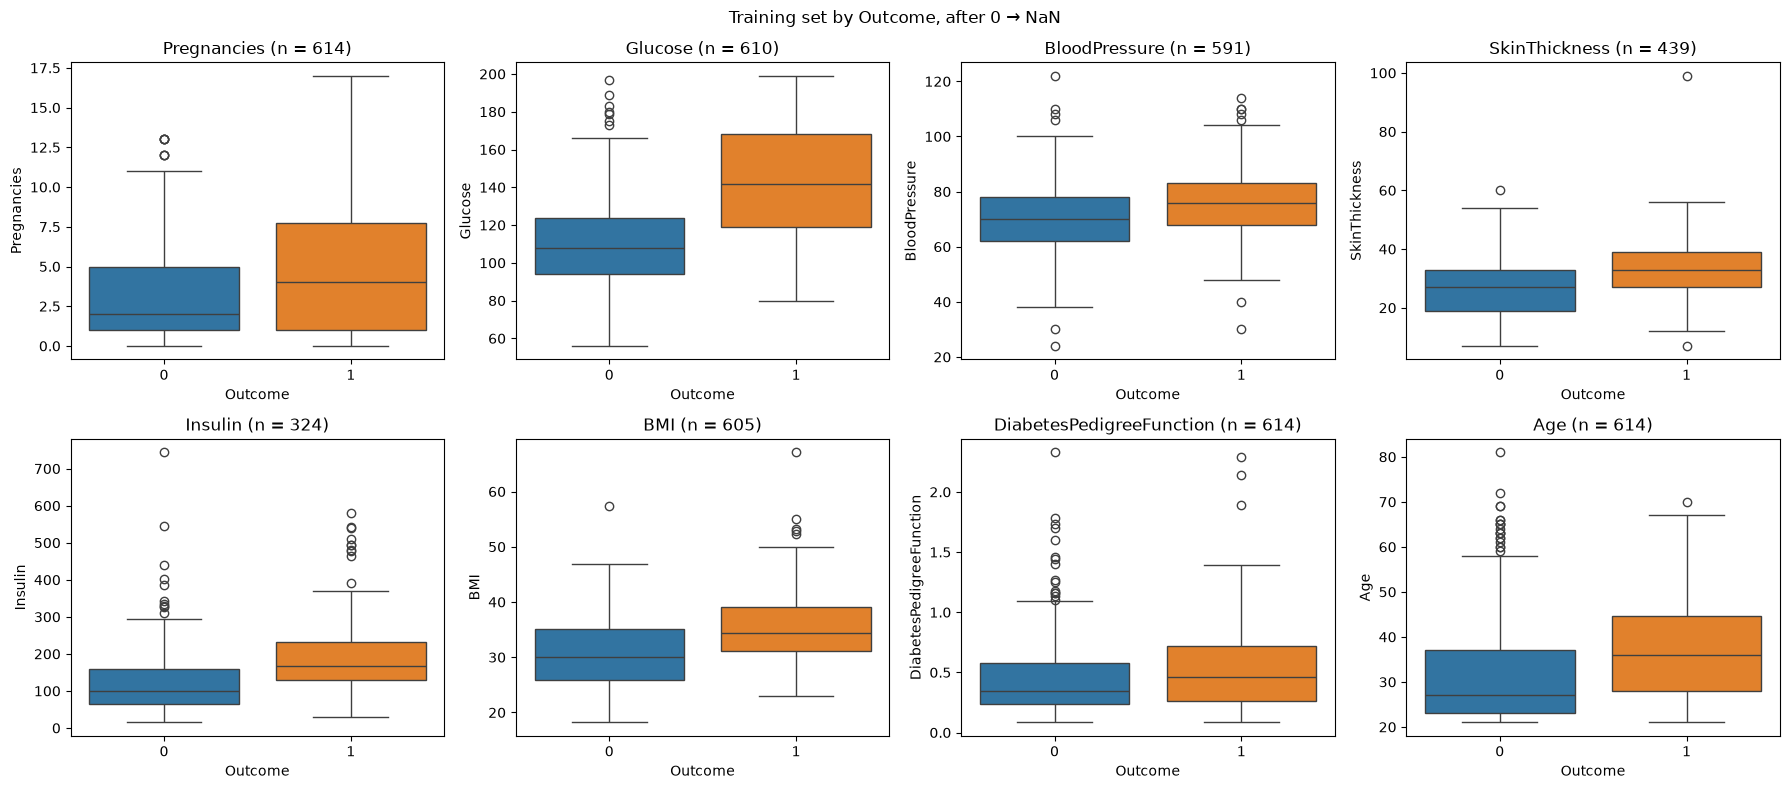

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=df_train, x="Outcome", y=col, hue="Outcome", legend=False, ax=ax)
    ax.set_title(f"{col} (n = {df_train[col].notna().sum()})")
plt.suptitle("Training set by Outcome, after 0 → NaN")
plt.tight_layout()
plt.show()

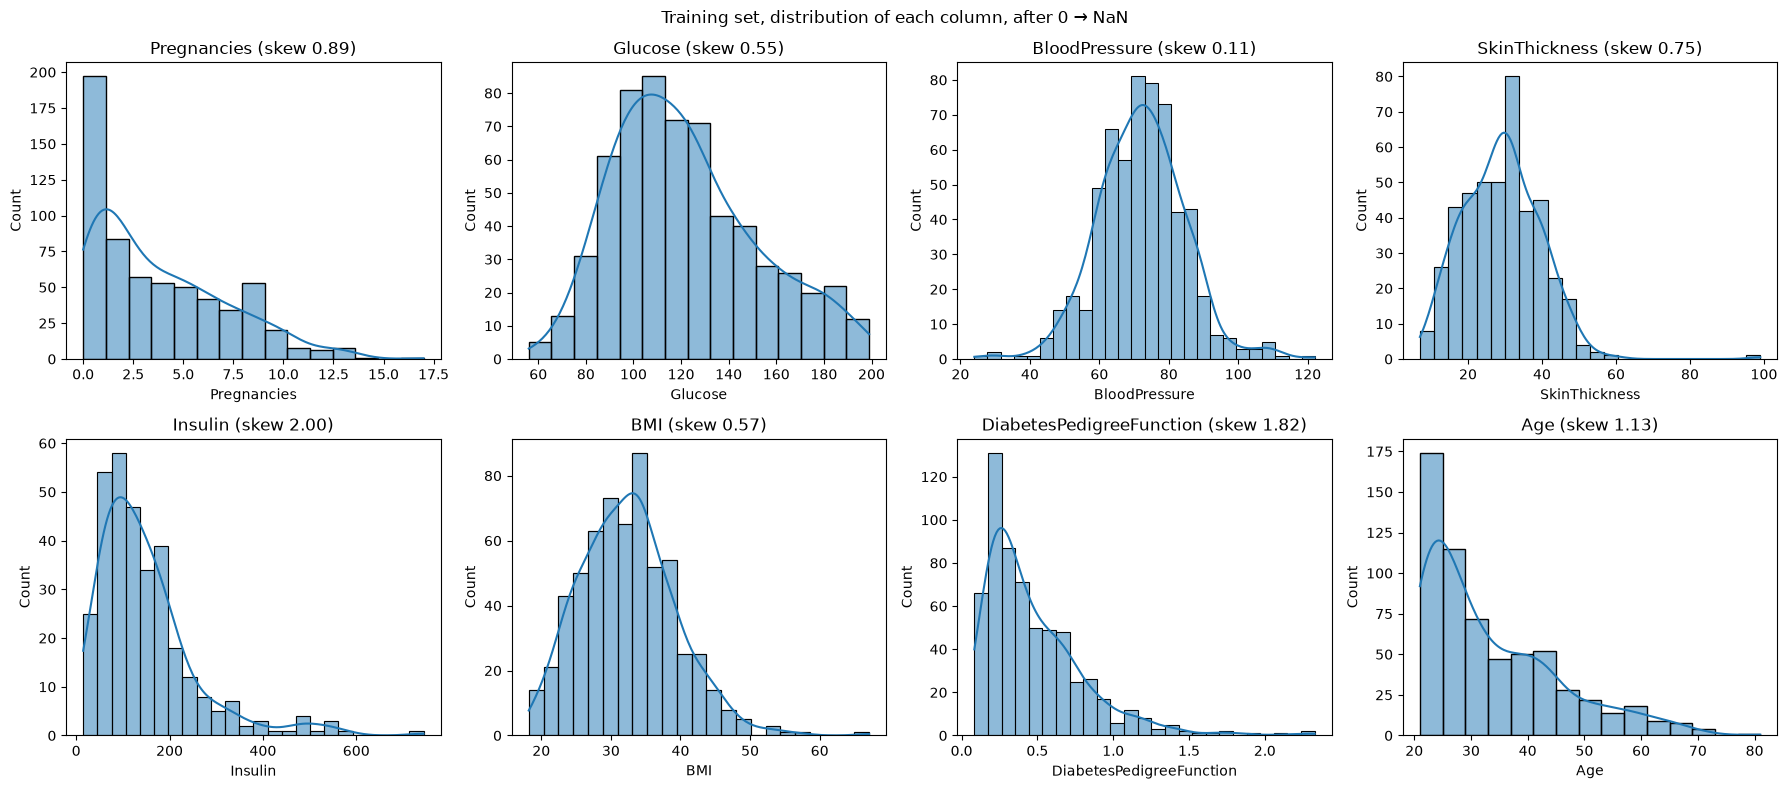

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(data=df_train, x=col, kde=True, ax=ax)
    ax.set_title(f"{col} (skew {df_train[col].skew():.2f})")
plt.suptitle("Training set, distribution of each column, after 0 → NaN")
plt.tight_layout()
plt.show()

In [16]:
df_train[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.82,3.31,0.00,1.00,3.00,6.00,17.00
Glucose,610.0,121.70,30.10,56.00,99.00,117.00,140.75,199.00
BloodPressure,591.0,72.15,12.51,24.00,64.00,72.00,80.00,122.00
SkinThickness,439.0,29.06,10.52,7.00,21.00,29.00,36.00,99.00
Insulin,324.0,149.08,107.23,15.00,76.00,125.00,183.50,744.00
BMI,605.0,32.45,6.87,18.20,27.60,32.40,36.60,67.10
DiabetesPedigreeFunction,614.0,0.48,0.33,0.08,0.24,0.38,0.64,2.33
Age,614.0,33.37,11.83,21.00,24.00,29.00,41.00,81.00


**What we see:**

- **Check against the paper:** the highest glucose value is **199**, just below the diabetic limit of 200. This fits the paper's selection rule (only examinations with a non-diabetic glucose test), so the Kaggle file is very likely the paper's data set. → "Found along the way".
- **Glucose separates the groups most clearly:** in the boxplots the boxes of Outcome 0 and 1 barely overlap (medians about 108 vs. 142). Glucose is therefore our candidate for the rule-based baseline in step 5. It is not one of our hypotheses, but it gets its turn there.
- **Outlier candidates:** SkinThickness 99 mm (the others lie between 7 and 60) and a diastolic blood pressure of 24 and 30 mmHg. They are unlikely, but not impossible, so we keep them (4.6). Insulin 744, BMI 67.1, 17 pregnancies and age 81 are rare but biologically possible.
- The many points beyond the whiskers in Insulin, DiabetesPedigreeFunction and Age come mainly from the skew, not from errors: the 1.5 × IQR rule assumes a roughly symmetric distribution.
- The `n` in each boxplot title shows how many values are left after 0 → NaN.

### 4.4 Correlations

Following the W2D1 table "two variables at a time":

- **feature × feature** (both numeric): **Pearson's r** measures how well a straight line fits. **Spearman's ρ** is Pearson's r on the ranks, so it measures any monotonic relationship ("the more ..., the more ...") and is less sensitive to skew and outliers. Both range from −1 to +1.
- **feature × `Outcome`** (numeric × category): the **correlation ratio η**, how much of the variation in a column the two `Outcome` groups explain. Range 0 to 1, no direction.

Where Pearson and Spearman differ clearly, the relationship is curved or driven by a few extreme values. All of these are descriptions, not tests: they do not count towards our three tests. NaNs are dropped pair by pair.

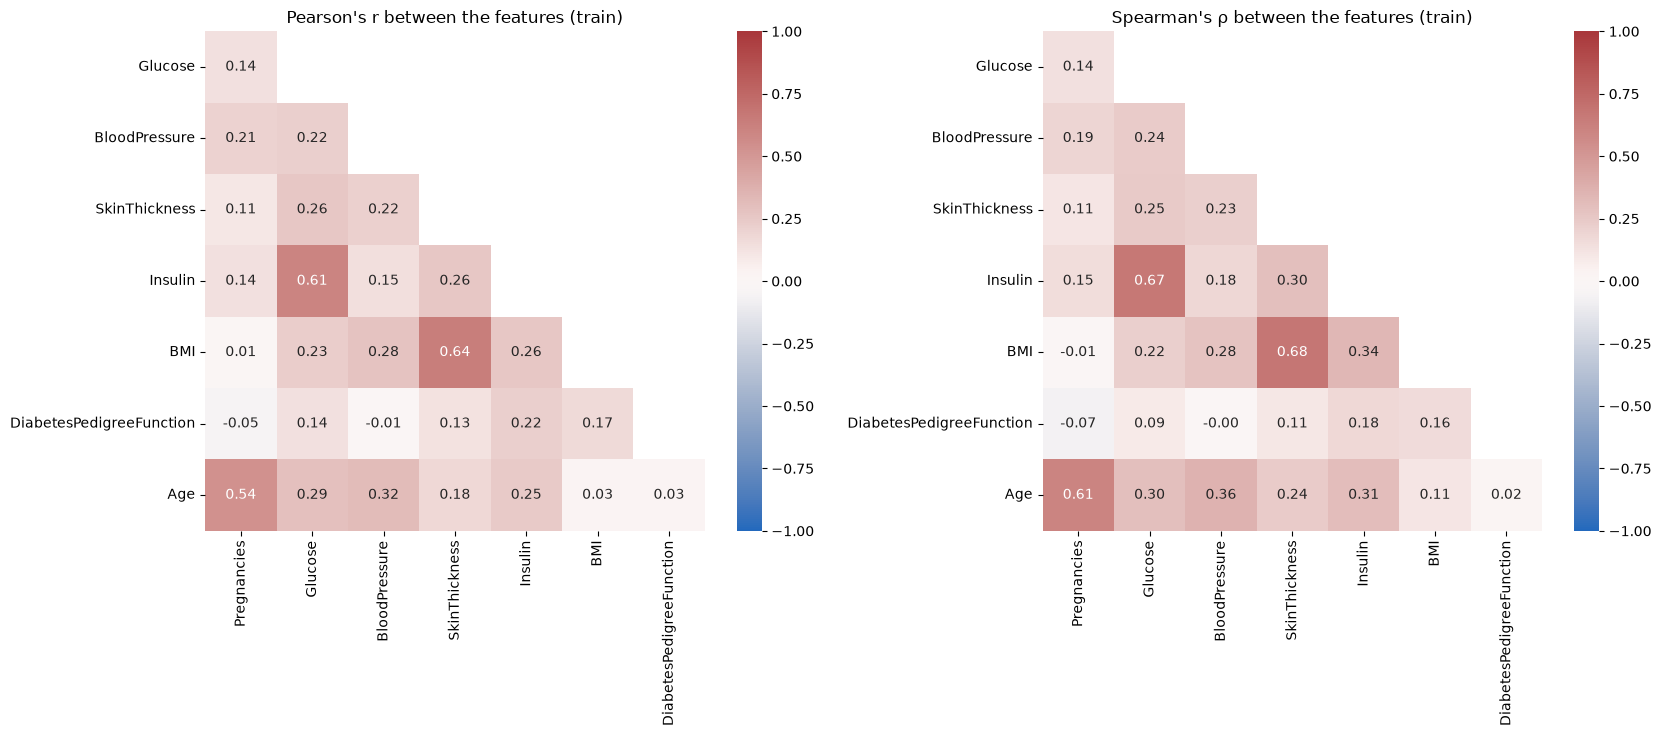

In [17]:
pearson = df_train[FEATURES].corr(method="pearson")
spearman = df_train[FEATURES].corr(method="spearman")

# Show only the lower half (the upper half mirrors it); drop the empty first row and last column
mask = np.triu(np.ones((len(FEATURES) - 1, len(FEATURES) - 1), dtype=bool), k=1)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, (name, matrix) in zip(axes, [("Pearson's r", pearson), ("Spearman's ρ", spearman)]):
    sns.heatmap(matrix.iloc[1:, :-1], mask=mask, annot=True, fmt=".2f", cmap="vlag",
                vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f"{name} between the features (train)")
plt.tight_layout()
plt.show()

In [18]:
# Which pairs do the two methods judge most differently?
pairs = []
for i, a in enumerate(FEATURES):
    for b in FEATURES[i + 1:]:
        pairs.append({"pair": f"{a} × {b}", "Pearson r": pearson.loc[a, b],
                      "Spearman ρ": spearman.loc[a, b]})
pairs = pd.DataFrame(pairs).set_index("pair")
pairs["difference ρ − r"] = pairs["Spearman ρ"] - pairs["Pearson r"]
pairs.reindex(pairs["difference ρ − r"].abs().sort_values(ascending=False).index).head(6).round(2)

,Pearson r,Spearman ρ,difference ρ − r
pair,,,
BMI × Age,0.03,0.11,0.08
Insulin × BMI,0.26,0.34,0.07
Pregnancies × Age,0.54,0.61,0.07
Glucose × Insulin,0.61,0.67,0.06
Insulin × Age,0.25,0.31,0.06
SkinThickness × Age,0.18,0.24,0.06


In [19]:
def correlation_ratio(values, groups):
    """η: share of the spread in `values` that the groups explain, as a square root (0 to 1)."""
    data = pd.DataFrame({"values": values, "groups": groups}).dropna()
    overall_mean = data["values"].mean()
    group_stats = data.groupby("groups")["values"].agg(["count", "mean"])
    ss_between = (group_stats["count"] * (group_stats["mean"] - overall_mean) ** 2).sum()
    ss_total = ((data["values"] - overall_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total)


# Each column against Outcome, with all three measures
with_outcome = pd.DataFrame({
    "Pearson r": df_train[FEATURES].corrwith(df_train["Outcome"], method="pearson"),
    "Spearman ρ": df_train[FEATURES].corrwith(df_train["Outcome"], method="spearman"),
    "η": {col: correlation_ratio(df_train[col], df_train["Outcome"]) for col in FEATURES},
})
with_outcome.sort_values("η", ascending=False).round(3)

,Pearson r,Spearman ρ,η
Glucose,0.515,0.494,0.515
Insulin,0.351,0.417,0.351
BMI,0.331,0.321,0.331
SkinThickness,0.280,0.286,0.280
Age,0.241,0.300,0.241
Pregnancies,0.208,0.183,0.208
BloodPressure,0.188,0.199,0.188
DiabetesPedigreeFunction,0.165,0.171,0.165


**What we see:**

*Feature × feature:*
- **Pearson and Spearman agree closely:** the largest difference is 0.08 (BMI × Age). Spearman is slightly higher wherever a skewed column is involved (Insulin, Age), because ranks dampen extreme values. There are no curved relationships that only Spearman would see.
- **Three strong pairs:**
  - **Pregnancies × Age (ρ = 0.61):** older women have had more pregnancies. For H2 this means we cannot tell from a simple test whether pregnancies or age drive the effect.
  - **Glucose × Insulin (ρ = 0.67):** both come from the same glucose tolerance test. Part of an insulin effect may be the glucose effect.
  - **SkinThickness × BMI (ρ = 0.68):** both measure body fat, so they carry partly the same information. Another reason for the model variant without SkinThickness.
- **No pair above 0.7:** no serious multicollinearity for the logistic regression, but we keep these pairs in mind when we read its coefficients.

*Feature × `Outcome`:*
- **η equals Pearson's r exactly.** That is no coincidence: with two groups, η is the same as the absolute value of Pearson's r with a 0/1 column (the point-biserial correlation). So η adds nothing new here.
- **Ranking:** Glucose ≈ 0.5, then Insulin, BMI and SkinThickness (about 0.3 to 0.4), the rest 0.3 or below.
- **Insulin:** Spearman (0.42) is clearly above Pearson (0.35), because the outliers press Pearson down. This supports the rank-based Mann-Whitney U test for H3.
- **Limits:** every number looks at one feature on its own. How much a feature adds *on top of* the others only the logistic regression shows. And these numbers are descriptions, not tests, so they do not count towards α.

### 4.5 Testing the three hypotheses

**What a test does:** it starts from the null hypothesis H0, "there is no difference between the groups", and asks how likely a result at least as extreme as ours would be if H0 were true. That probability is the p-value. A small p-value means: our data fit badly with H0, so we reject it. A large p-value does **not** prove H0 ("fail to reject ≠ accept"), it only means the data are not clear enough.

**Significance level:** we run three tests. With α = 0.05 each, the chance of at least one false alarm would be about 1 − 0.95³ ≈ 14 %. Bonferroni divides α by the number of tests: **α = 0.05 / 3 ≈ 0.0167**. This was fixed in step 1.

**p-value and effect size belong together:** the p-value says whether a difference is probably real, the effect size says how large it is. With many patients, even a tiny difference can become significant, so we report both.

**Which test, and why** (from the test plan in step 1 and the distributions in 4.2):

| | Column | Test | Why |
| :-- | :-- | :-- | :-- |
| H1 | `BMI` | Mann-Whitney U, one-tailed (Outcome 1 greater) | Shapiro rejects normality in both groups (4.2), so we use the rank-based test. The hypothesis has a direction. |
| H2 | `Pregnancies` in bands 0 / 1–3 / 4–6 / 7+ | χ² test of independence | Two categorical variables (band × `Outcome`). |
| H3 | `Insulin` | Mann-Whitney U, two-tailed | Strongly skewed (skew 2.69 and 1.52), and the direction is open. |

**Mann-Whitney U in one sentence:** it puts all values of both groups in one ranking and checks whether one group tends to sit higher in that ranking than the other. It compares ranks, not means, so a few extreme values cannot dominate. Its effect size is the **rank-biserial correlation** r = 2 · U / (n₁ · n₂) − 1: +1 means every patient with diabetes has a higher value than every patient without, 0 means no tendency, −1 the opposite.

In [20]:
ALPHA = 0.05 / 3


def mann_whitney(col, alternative):
    """Mann-Whitney U between Outcome 1 and Outcome 0 on the training set, NaNs dropped."""
    with_diabetes = df_train.loc[df_train["Outcome"] == 1, col].dropna()
    without_diabetes = df_train.loc[df_train["Outcome"] == 0, col].dropna()
    u, p = stats.mannwhitneyu(with_diabetes, without_diabetes, alternative=alternative)
    rank_biserial = 2 * u / (len(with_diabetes) * len(without_diabetes)) - 1
    return {
        "column": col, "test": f"Mann-Whitney U ({alternative})",
        "n Outcome 1": len(with_diabetes), "n Outcome 0": len(without_diabetes),
        "median Outcome 1": with_diabetes.median(), "median Outcome 0": without_diabetes.median(),
        "U": u, "p": p, "effect size": f"rank-biserial r = {rank_biserial:.2f}",
        "significant at α = 0.0167": p < ALPHA,
    }

#### H1: BMI

H0: the BMI values of women who develop diabetes do not tend to be higher than those of women who do not. H1 (one-tailed): they tend to be higher. Plot: the BMI panel in 4.2 and the BMI boxplot in 4.3.

In [21]:
h1 = mann_whitney("BMI", alternative="greater")
pd.Series({**h1, "p": f"{h1['p']:.2e}"})

column                                            BMI
test                         Mann-Whitney U (greater)
n Outcome 1                                       212
n Outcome 0                                       393
median Outcome 1                                34.35
median Outcome 0                                 30.1
U                                             57832.5
p                                            1.57e-15
effect size                    rank-biserial r = 0.39
significant at α = 0.0167                        True
dtype: object

**What we see:** p = 1.6e-15 lies far below α = 0.0167, so we reject H0. The median BMI is 34.35 in the diabetes group and 30.1 in the other group.

**How to read the effect size:** rank-biserial r = 0.39. Turned into a probability: (r + 1) / 2 = 0.70. If we draw one woman who develops diabetes and one who does not, the first has the higher BMI in **70 % of the pairs** (50 % would mean no relationship). A medium effect.

**What exactly was tested:** that the BMI values of the diabetes group *tend to be higher* (their ranks), not that the mean is higher. → **H1 supported.**

#### H2: Pregnancies

The χ² test compares the observed counts in each cell of the table band × `Outcome` with the counts we would expect if the share of diabetes were the same in every band. The larger the gap, the larger χ² and the smaller p. Requirement: at least 5 expected cases per cell, which we check.

**Limitation:** χ² only asks *whether* the share of diabetes differs between the bands, not *in which direction*. Our hypothesis says "the more pregnancies, the more likely". So we read the direction from the share of diabetes per band, and the verdict only counts as "supported" if the shares rise with the bands.

**Effect size: Cramér's V**, from 0 (no relationship) to 1 (the band determines the outcome completely). Rough guide for a table with two columns: 0.1 small, 0.3 medium, 0.5 large.

In [22]:
PREGNANCY_BANDS = [-0.5, 0.5, 3.5, 6.5, np.inf]
PREGNANCY_LABELS = ["0", "1–3", "4–6", "7+"]

pregnancy_band = pd.cut(df_train["Pregnancies"], bins=PREGNANCY_BANDS, labels=PREGNANCY_LABELS)
observed = pd.crosstab(pregnancy_band, df_train["Outcome"])

chi2, p, dof, expected = stats.chi2_contingency(observed)
cramers_v = np.sqrt(chi2 / (observed.to_numpy().sum() * (min(observed.shape) - 1)))

band_table = observed.copy()
band_table.columns = ["Outcome 0", "Outcome 1"]
band_table["share with diabetes"] = (observed[1] / observed.sum(axis=1)).round(3)
band_table["smallest expected count"] = expected.min(axis=1).round(1)
display(band_table)

h2 = {
    "column": "Pregnancies (bands)", "test": "chi² test of independence",
    "chi²": chi2, "degrees of freedom": dof, "p": p,
    "effect size": f"Cramér's V = {cramers_v:.2f}", "significant at α = 0.0167": p < ALPHA,
}
pd.Series({**h2, "p": f"{h2['p']:.2e}"})

,Outcome 0,Outcome 1,share with diabetes,smallest expected count
Pregnancies,,,,
0,54,31,0.365,29.6
1–3,191,62,0.245,88.2
4–6,98,47,0.324,50.5
7+,57,74,0.565,45.7


column                             Pregnancies (bands)
test                         chi² test of independence
chi²                                         39.413912
degrees of freedom                                   3
p                                             1.42e-08
effect size                          Cramér's V = 0.25
significant at α = 0.0167                         True
dtype: object

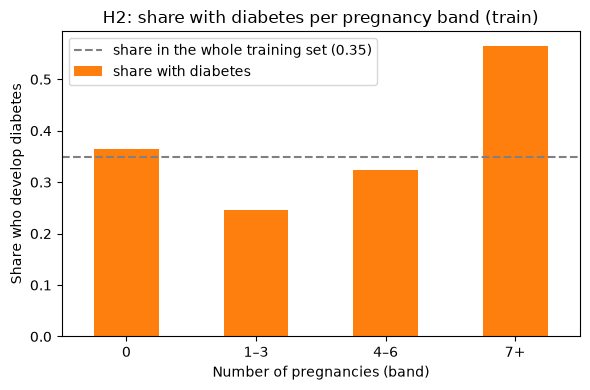

In [23]:
ax = band_table["share with diabetes"].plot(kind="bar", color="tab:orange", figsize=(6, 4), rot=0)
ax.axhline(p_train, color="grey", linestyle="--", label=f"share in the whole training set ({p_train:.2f})")
ax.set_xlabel("Number of pregnancies (band)")
ax.set_ylabel("Share who develop diabetes")
ax.set_title("H2: share with diabetes per pregnancy band (train)")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Is the band 7+ simply the oldest group? (Spearman Pregnancies × Age = 0.61, see 4.4)
df_train.groupby(pregnancy_band, observed=True)["Age"].agg(["median", "mean"]).round(1)

,median,mean
Pregnancies,,
0,24.0,27.5
1–3,25.0,27.7
4–6,34.0,37.8
7+,42.0,43.2


**What we see:**

- **Requirement met:** the smallest expected count is 29.6, well above 5.
- **χ² = 39.4 with 3 degrees of freedom** ((4 bands − 1) × (2 outcomes − 1)), **p = 1.4e-8**: the share of diabetes depends on the band. **Cramér's V = 0.25**, a small to medium effect.
- **But the pattern is not "the more, the more often":** band 0 has 0.37, band 1–3 only 0.25, band 4–6 0.32, and band 7+ jumps to 0.57. The share only rises from 4–6 on.
- **Age:** band 7+ is also the oldest group (median age 42, compared with 24, 25 and 34). With Spearman ρ = 0.61 between Pregnancies and Age, this test cannot separate the two.
- **Verdict:** before the test we fixed that χ² only says *whether* there is a relationship, and that H2 only counts as supported if the shares rise with the bands. They do not rise steadily → **H2 cannot tell yet.**
- **Band 0 above 1–3** is a surprise and goes into "Found along the way". With 85 women it is a small group: 31 of 85 can easily vary by about ±10 percentage points.

#### H3: Insulin

H0: the insulin values of the two groups do not differ in their tendency. H1 (two-tailed): they differ, in either direction. Only the 324 training rows with a measured insulin value take part (4.1: insulin is missing about equally often in both groups, 46 % and 49 %). Plot: the insulin panel in 4.2 and the insulin boxplot in 4.3.

In [25]:
h3 = mann_whitney("Insulin", alternative="two-sided")
pd.Series({**h3, "p": f"{h3['p']:.2e}"})

column                                          Insulin
test                         Mann-Whitney U (two-sided)
n Outcome 1                                         109
n Outcome 0                                         215
median Outcome 1                                  168.0
median Outcome 0                                  100.0
U                                               17691.5
p                                              6.46e-14
effect size                      rank-biserial r = 0.51
significant at α = 0.0167                          True
dtype: object

**What we see:** only the 324 rows with a measured insulin value take part (109 with and 215 without diabetes). p = 6.5e-14, so we reject H0. The median insulin is 168 in the diabetes group and 100 in the other group.

- **Effect size:** r = 0.51, so (r + 1) / 2 = 0.76: in three of four pairs the woman who develops diabetes has the higher insulin value. The largest effect of the three tests.
- **The open direction is answered: higher.** This fits insulin resistance: the body releases more insulin to keep blood sugar down. That is the early stage, which is what we would expect when diabetes is diagnosed only 1 to 5 years *later*.
- **Limits:** the test only uses 324 of 614 rows (missing about equally often in both groups, 4.1), and insulin correlates with glucose (ρ = 0.67), so part of the effect is probably the glucose effect. → **H3 supported, direction: higher.**

#### Summary of the three tests

In [26]:
summary = pd.DataFrame([h1, h2, h3]).set_index("column")[["test", "p", "effect size", "significant at α = 0.0167"]]
summary["p"] = summary["p"].map("{:.2e}".format)
summary

,test,p,effect size,significant at α = 0.0167
column,,,,
BMI,Mann-Whitney U (greater),1.57e-15,rank-biserial r = 0.39,True
Pregnancies (bands),chi² test of independence,1.42e-08,Cramér's V = 0.25,True
Insulin,Mann-Whitney U (two-sided),6.46e-14,rank-biserial r = 0.51,True


### 4.6 Cleaning: fill the missing values with the training medians

The tests above ran on the NaN version on purpose: filling half of the insulin column with one value would have blurred the difference between the groups. For the model we now need complete rows, because `LogisticRegression` cannot handle NaN.

**Fill or drop?** The W2D1 slides list five options, from fewest to most assumptions: drop the rows, fill with a constant, fill with the mean or median, interpolate, predict from the other columns. And they warn: "Cleaning decisions are analysis decisions." Dropping rows changes who is in the sample, and filling narrows the spread and pulls correlations towards zero. Here is what each option would mean for our data:

| Option | What it would mean here | Decision |
| :-- | :-- | :-- |
| Drop every row with a NaN | Only 322 of 614 training rows are complete. Almost half of the patients would be gone, and the model would only learn from women who had the full examination. | no, too costly |
| Drop the columns `Insulin` and `SkinThickness` | All rows stay, but we lose insulin, the second strongest signal (H3: r = 0.51). | as a **variant** in step 6 |
| Fill with the training median | Rows and columns stay. For Glucose, BloodPressure and BMI (under 5 % missing) this is harmless. For Insulin (47 % missing) it creates a big spike at 125 and weakens the relationship. | **main version** |
| Add a "was measured" column (0/1) | Useful if the gap itself carries information (MNAR). Here missingness hardly depends on `Outcome` (4.1), so there is little to gain. | not used |

So we fill with the median **and** train a variant without the two columns. If the scores of the two versions differ clearly, the filled values matter, and we say so ("Try the alternative, and see whether the conclusion moves").

**Why the median:** four of the five columns are skewed (skew 0.55 to 2.00, see 4.2). The median is not pulled by the long right tail, the mean is. For `BloodPressure` (skew 0.11) median and mean are almost the same, so one rule for all five columns keeps it simple.

**Why only training medians:** the test set stands in for new patients. We would not know their values in advance, so we must not compute anything from them. In step 8 the test set is filled with exactly these training medians.

**Cleaning log** (applied in the same order to `df_test` in step 8):

1. 0 → NaN in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` (before the split, rule fixed in advance).
2. NaN → training median of the column (values in `TRAIN_MEDIANS` below).
3. Outlier candidates (SkinThickness 99, BloodPressure 24 and 30) are **kept**: they are unlikely but not impossible, and deleting real patients on suspicion would distort the data.
4. Model variant for step 6: one model **without `Insulin` and `SkinThickness`**, because after filling, 47 % and 29 % of their values are the same median. If the results move clearly, the filled values matter ("try the alternative").

In [27]:
TRAIN_MEDIANS = df_train[ZERO_MEANS_MISSING].median()
TRAIN_MEDIANS

Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64

In [28]:
def apply_cleaning(data, medians):
    """Same cleaning for train and test: fill the NaNs from 0 → NaN with the given (training) medians."""
    cleaned = data.copy()
    cleaned[ZERO_MEANS_MISSING] = cleaned[ZERO_MEANS_MISSING].fillna(medians)
    return cleaned


df_train_clean = apply_cleaning(df_train, TRAIN_MEDIANS)

assert df_train_clean.isna().sum().sum() == 0, "there are still NaNs in the training set"
assert list(df_train_clean.columns) == list(df_train.columns)
print("NaNs left in df_train_clean:", df_train_clean.isna().sum().sum())
print("Rows with the median filled in, per column:")
df_train[ZERO_MEANS_MISSING].isna().sum()

NaNs left in df_train_clean: 0
Rows with the median filled in, per column:


Glucose            4
BloodPressure     23
SkinThickness    175
Insulin          290
BMI                9
dtype: int64

**What we see:** the training medians are Glucose 117, BloodPressure 72, SkinThickness 29, Insulin 125 and BMI 32.4. After filling, no NaN is left, and the columns are unchanged (both checked with `assert`). The last output shows how many values per column were filled in: 290 for Insulin and 175 for SkinThickness, but only 4 for Glucose. `df_test` stays untouched until step 8. There, `apply_cleaning(df_test, TRAIN_MEDIANS)` fills it with exactly these training values.

## Step 5: Features, target and two baselines

**Why baselines:** a score on its own says nothing. F2 = 0.7 sounds good, but is it better than guessing? A baseline is the simplest thing that could work. A model only counts to the extent that it beats it.

**The two baselines from the task, plus one reference:**

| | What it does | Why |
| :-- | :-- | :-- |
| Random baseline | `DummyClassifier(strategy="stratified")` guesses "diabetes" at random in 34.9 % of cases, the share in the training set | The floor: what you get without any information |
| Rule-based baseline | "Glucose ≥ cutoff means diabetes" | Glucose separates the groups most clearly (4.3, 4.4). One column and one number: what a doctor could do with a single lab value |
| Reference: everyone has diabetes | Predicts 1 for every patient | Not required by the task, but it shows why we need `P_MIN` (see below) |

**How we choose the glucose cutoff:** with the same rule as for the model later: the cutoff with the **highest F2 among those with precision ≥ `P_MIN`**, chosen on the training data. Only then is the comparison between baseline and model fair. If we chose the cutoff by accuracy and judged the model by F2, the baseline would be weak by construction.

**Which data:** `df_train_clean` from 4.6 (missing values filled with training medians). All scores in this step are **training scores**. The test scores follow in step 8.

In [ ]:
TARGET = "Outcome"
FEATURES_WITHOUT_INSULIN_SKIN = [col for col in FEATURES if col not in ["Insulin", "SkinThickness"]]

X_train = df_train_clean[FEATURES]
y_train = df_train_clean[TARGET]
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("Features of variant B (without Insulin and SkinThickness):", FEATURES_WITHOUT_INSULIN_SKIN)

**One function for all scores:** every model is scored the same way, so the table at the end compares like with like. F2 is our main metric, precision and recall show what F2 is made of, accuracy is only a warning light. `meets P_min` says whether the model keeps our precision floor.

In [ ]:
def classification_scores(y_true, y_pred):
    """The scores we report for every model: F2 (main metric), precision, recall, accuracy."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    return {
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "meets P_min": precision >= P_MIN,
    }


train_results = {}  # model name -> training scores, filled step by step

### 5.1 Random baseline

In [ ]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
train_results["random baseline"] = classification_scores(y_train, dummy.predict(X_train))

train_results["reference: everyone has diabetes"] = classification_scores(y_train, np.ones(len(y_train), dtype=int))

pd.DataFrame.from_dict(train_results, orient="index").round(3)

**What we see:**

- **Random baseline:** precision and recall are both about 0.34, F2 = 0.34. That is what guessing in the right proportion gives: of the 34.9 % flagged, 34.9 % are real cases by chance. Accuracy is 0.54, which shows why accuracy is only a warning light: it sounds like "half right", but the model knows nothing. It does not meet the precision floor either.
- **Everyone has diabetes: F2 = 0.73.** It finds every case (recall = 1.0), and because F2 weights recall four times as heavily as precision, this useless model gets a high F2. This matches the formula from the planning: F2 = 5p / (4p + 1) = 0.728 for p = 0.349.
- **This is exactly why we fixed `P_MIN`:** its precision is only 0.349, below 0.5, so `meets P_min` is `False` and it does not count. Without the floor, F2 alone would reward models that call almost everyone sick.

### 5.2 Rule-based baseline: glucose cutoff

We try every glucose value in the training set as a cutoff, compute the scores for "glucose ≥ cutoff means diabetes", keep only the cutoffs with precision ≥ `P_MIN`, and take the one with the highest F2.

In [ ]:
def rule_predict(data, cutoff):
    """Rule-based baseline: 1 (diabetes) if glucose is at or above the cutoff."""
    return (data["Glucose"] >= cutoff).astype(int)


cutoff_table = pd.DataFrame([
    {"cutoff": cutoff, **classification_scores(y_train, rule_predict(X_train, cutoff))}
    for cutoff in np.sort(X_train["Glucose"].unique())
])

allowed = cutoff_table[cutoff_table["meets P_min"]]
GLUCOSE_CUTOFF = allowed.loc[allowed["F2"].idxmax(), "cutoff"]
best_without_floor = cutoff_table.loc[cutoff_table["F2"].idxmax()]

print(f"Chosen cutoff (highest F2 with precision >= {P_MIN}): glucose >= {GLUCOSE_CUTOFF:.0f}")
print(f"Without the floor, F2 would pick glucose >= {best_without_floor['cutoff']:.0f} "
      f"(precision {best_without_floor['precision']:.2f})")

train_results[f"rule: glucose >= {GLUCOSE_CUTOFF:.0f}"] = classification_scores(y_train, rule_predict(X_train, GLUCOSE_CUTOFF))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for score in ["F2", "precision", "recall"]:
    ax.plot(cutoff_table["cutoff"], cutoff_table[score], label=score)
ax.axhline(P_MIN, color="grey", linestyle="--", label=f"P_min = {P_MIN}")
ax.axvline(GLUCOSE_CUTOFF, color="black", linestyle=":", label=f"chosen cutoff = {GLUCOSE_CUTOFF:.0f}")
ax.set_xlabel("Glucose cutoff (mg/dl)")
ax.set_ylabel("Score on the training set")
ax.set_title("Rule-based baseline: scores for every glucose cutoff")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame.from_dict(train_results, orient="index").round(3)

**What we see:**

- **The curves:** a low cutoff flags almost everyone, so recall is high and precision low. A high cutoff flags only clear cases, so precision rises and recall falls. F2 peaks at a low cutoff, because it values recall four times as much.
- **Chosen cutoff: glucose ≥ 112.** Below 112, precision drops under 0.5. At 112 the rule finds 83 % of the future cases (recall 0.83), and every second alarm is a real case (precision 0.50). F2 = 0.73.
- **Without the floor**, F2 would choose glucose ≥ 100: recall 0.94, but precision only 0.44, so more than half of the alarms would be false. The floor stops that.
- **The rule beats the random baseline clearly** (F2 0.73 vs. 0.34). Its F2 is about the same as "everyone has diabetes", but the rule keeps the precision floor and the reference does not. This is the bar the logistic regression has to clear: **F2 above 0.73 with precision ≥ 0.5.**
- **Caution:** the cutoff was chosen on the training data and scored on the same data, so 0.73 is slightly optimistic. The honest number comes from the test set in step 8.

In [29]:
# Your code here

